In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r"C:\Users\surya.adatravu\Documents\RAG_HRETREIVER\results_hybrid_vs_dense_1.csv")

In [3]:
df['s0']=0
df['s1']=0

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def sentence_similarity(sent1, sent2):
    """
    Returns 1 if cosine similarity between two sentences is above 0.7, else 0.
    """
    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform([sent1, sent2])
    
    similarity = cosine_similarity(tfidf_matrix[0:1], tfidf_matrix[1:2])[0][0]
    #print(similarity)
    
    return 1 if similarity > 0.5 else 0

# Example usage
#result = sentence_similarity("The cat sits on the mat.", "A cat is sitting on the rug.")
#print(result)  # Outputs 1 or 0 depending on similarity


In [5]:
df.head()

,Question,Answer,t_dense,t_hybrid,ans_dense,ans_hybrid,src_dense,src_hybrid,s0,s1
0,What is RA–FSM?,"RA–FSM is a modular, GPT-based research assist...",4.350,3.995,RA–FSM is a retrieval assistant that utilizes ...,RA–FSM is a finite-state machine (FSM) that se...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
1,What problem does RA–FSM aim to solve?,It mitigates hallucinations and citation fabri...,2.980,4.053,RA–FSM aims to solve issues related to citatio...,RA–FSM aims to solve issues related to citatio...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
2,What are the three core states of the RA–FSM c...,"The three states are Relevance, Confidence, an...",4.471,3.176,The three core states of the RA–FSM control lo...,The three core states of the RA–FSM control lo...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
3,What does the Relevance state do?,It checks if the user's question is within the...,1.812,4.060,Relevant : Yes,Relevant : No,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
4,What is the function of the Confidence state?,It assesses whether the system can answer a qu...,3.264,5.462,The function of the Confidence Check state is ...,"The Confidence state, also referred to as the ...",data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0


In [6]:
check_sentence="I don't know."
for i1 in range(df.shape[0]):
    df.loc[i1,'s0']=sentence_similarity(df.loc[i1,'ans_dense'], check_sentence)
    df.loc[i1,'s1']=sentence_similarity(df.loc[i1,'ans_hybrid'], check_sentence)

In [7]:
df.head()

,Question,Answer,t_dense,t_hybrid,ans_dense,ans_hybrid,src_dense,src_hybrid,s0,s1
0,What is RA–FSM?,"RA–FSM is a modular, GPT-based research assist...",4.350,3.995,RA–FSM is a retrieval assistant that utilizes ...,RA–FSM is a finite-state machine (FSM) that se...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
1,What problem does RA–FSM aim to solve?,It mitigates hallucinations and citation fabri...,2.980,4.053,RA–FSM aims to solve issues related to citatio...,RA–FSM aims to solve issues related to citatio...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
2,What are the three core states of the RA–FSM c...,"The three states are Relevance, Confidence, an...",4.471,3.176,The three core states of the RA–FSM control lo...,The three core states of the RA–FSM control lo...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
3,What does the Relevance state do?,It checks if the user's question is within the...,1.812,4.060,Relevant : Yes,Relevant : No,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0
4,What is the function of the Confidence state?,It assesses whether the system can answer a qu...,3.264,5.462,The function of the Confidence Check state is ...,"The Confidence state, also referred to as the ...",data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0


In [8]:
df.to_csv("result_b0.csv")

In [9]:
df['quality0']=0
df['quality1']=0

In [10]:
for i1 in range(df.shape[0]):
    df.loc[i1,'quality0']=sentence_similarity(df.loc[i1,'ans_dense'], df.loc[i1,'Answer'])
    df.loc[i1,'quality1']=sentence_similarity(df.loc[i1,'ans_hybrid'], df.loc[i1,'Answer'])

In [11]:
from rouge_score import rouge_scorer
import pandas as pd

def add_rouge_scores(
    df: pd.DataFrame,
    reference_col: str,
    prediction_col: str,
    use_stemmer: bool = True
) -> pd.DataFrame:
    """
    Adds ROUGE-1, ROUGE-2, and ROUGE-L precision, recall, and F1 columns
    to the dataframe and returns it.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing reference and prediction columns
        reference_col (str): Name of the reference/ground-truth column
        prediction_col (str): Name of the model output column
        use_stemmer (bool): Whether to stem words (default True)
        
    Returns:
        pd.DataFrame: Original DataFrame with added ROUGE metric columns
    """
    scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=use_stemmer)

    rouge1_p, rouge1_r, rouge1_f = [], [], []
    rouge2_p, rouge2_r, rouge2_f = [], [], []
    rougeL_p, rougeL_r, rougeL_f = [], [], []

    for ref, pred in zip(df[reference_col], df[prediction_col]):
        scores = scorer.score(str(ref), str(pred))

        rouge1_p.append(scores["rouge1"].precision)
        rouge1_r.append(scores["rouge1"].recall)
        rouge1_f.append(scores["rouge1"].fmeasure)

        rouge2_p.append(scores["rouge2"].precision)
        rouge2_r.append(scores["rouge2"].recall)
        rouge2_f.append(scores["rouge2"].fmeasure)

        rougeL_p.append(scores["rougeL"].precision)
        rougeL_r.append(scores["rougeL"].recall)
        rougeL_f.append(scores["rougeL"].fmeasure)

    # Add columns to DataFrame
    df["rouge1_precision"] = rouge1_p
    df["rouge1_recall"] = rouge1_r
    df["rouge1_f1"] = rouge1_f

    df["rouge2_precision"] = rouge2_p
    df["rouge2_recall"] = rouge2_r
    df["rouge2_f1"] = rouge2_f

    df["rougeL_precision"] = rougeL_p
    df["rougeL_recall"] = rougeL_r
    df["rougeL_f1"] = rougeL_f

    return df


In [12]:
#!pip install rouge-score

In [14]:
df1=add_rouge_scores(df,'Answer','ans_dense')

In [15]:
df2=add_rouge_scores(df,'Answer','ans_hybrid')

In [16]:
df1.head()

,Question,Answer,t_dense,t_hybrid,ans_dense,ans_hybrid,src_dense,src_hybrid,s0,s1,...,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1
0,What is RA–FSM?,"RA–FSM is a modular, GPT-based research assist...",4.350,3.995,RA–FSM is a retrieval assistant that utilizes ...,RA–FSM is a finite-state machine (FSM) that se...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.226667,0.629630,0.333333,0.081081,0.230769,0.120000,0.133333,0.370370,0.196078
1,What problem does RA–FSM aim to solve?,It mitigates hallucinations and citation fabri...,2.980,4.053,RA–FSM aims to solve issues related to citatio...,RA–FSM aims to solve issues related to citatio...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.070423,0.357143,0.117647,0.000000,0.000000,0.000000,0.042254,0.214286,0.070588
2,What are the three core states of the RA–FSM c...,"The three states are Relevance, Confidence, an...",4.471,3.176,The three core states of the RA–FSM control lo...,The three core states of the RA–FSM control lo...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,1,0.363636,1.000000,0.533333,0.238095,0.714286,0.357143,0.363636,1.000000,0.533333
3,What does the Relevance state do?,It checks if the user's question is within the...,1.812,4.060,Relevant : Yes,Relevant : No,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,What is the function of the Confidence state?,It assesses whether the system can answer a qu...,3.264,5.462,The function of the Confidence Check state is ...,"The Confidence state, also referred to as the ...",data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.111111,0.600000,0.187500,0.025000,0.142857,0.042553,0.074074,0.400000,0.125000


In [17]:
df2.head()

,Question,Answer,t_dense,t_hybrid,ans_dense,ans_hybrid,src_dense,src_hybrid,s0,s1,...,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1
0,What is RA–FSM?,"RA–FSM is a modular, GPT-based research assist...",4.350,3.995,RA–FSM is a retrieval assistant that utilizes ...,RA–FSM is a finite-state machine (FSM) that se...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.226667,0.629630,0.333333,0.081081,0.230769,0.120000,0.133333,0.370370,0.196078
1,What problem does RA–FSM aim to solve?,It mitigates hallucinations and citation fabri...,2.980,4.053,RA–FSM aims to solve issues related to citatio...,RA–FSM aims to solve issues related to citatio...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.070423,0.357143,0.117647,0.000000,0.000000,0.000000,0.042254,0.214286,0.070588
2,What are the three core states of the RA–FSM c...,"The three states are Relevance, Confidence, an...",4.471,3.176,The three core states of the RA–FSM control lo...,The three core states of the RA–FSM control lo...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,1,0.363636,1.000000,0.533333,0.238095,0.714286,0.357143,0.363636,1.000000,0.533333
3,What does the Relevance state do?,It checks if the user's question is within the...,1.812,4.060,Relevant : Yes,Relevant : No,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,What is the function of the Confidence state?,It assesses whether the system can answer a qu...,3.264,5.462,The function of the Confidence Check state is ...,"The Confidence state, also referred to as the ...",data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,data\RA_FSM_Paper 2.pdf;data\RA_FSM_Paper 2.pd...,0,0,...,0,0.111111,0.600000,0.187500,0.025000,0.142857,0.042553,0.074074,0.400000,0.125000


In [18]:
df_1=df1[df1['s0']==0]
df_2=df2[df2['s0']==0]
df_1['diff_t']=df_1['t_dense']-df_1['t_hybrid']

C:\Users\surya.adatravu\AppData\Local\Temp\ipykernel_18884\3811853088.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1['diff_t']=df_1['t_dense']-df_1['t_hybrid']


In [19]:
df_1.shape

(42, 22)

In [20]:
df_2.shape

(42, 21)

In [21]:
df_1.describe()[['diff_t','t_dense','t_hybrid']]

,diff_t,t_dense,t_hybrid
count,42.000000,42.000000,42.000000
mean,-0.163143,2.743643,2.906786
std,1.259203,0.870477,1.312403
min,-4.025000,1.591000,1.274000
25%,-0.641000,1.980000,1.889250
50%,0.049500,2.729500,2.603000
75%,0.545750,3.249500,3.922250
max,2.562000,5.149000,6.665000


In [22]:
# df_1=df1[df1['s0']==0]
# df_2=df2[df2['s0']==0]
df_2['diff_t']=df_2['t_dense']-df_2['t_hybrid']

C:\Users\surya.adatravu\AppData\Local\Temp\ipykernel_18884\3885311047.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2['diff_t']=df_2['t_dense']-df_2['t_hybrid']


In [23]:
df_2.describe()

,t_dense,t_hybrid,s0,s1,quality0,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1,diff_t
count,42.000000,42.000000,42.0,42.000000,42.0,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,2.743643,2.906786,0.0,0.119048,0.0,0.023810,0.131424,0.535175,0.203034,0.053442,0.220864,0.083253,0.114112,0.455304,0.175733,-0.163143
std,0.870477,1.312403,0.0,0.327770,0.0,0.154303,0.096743,0.310252,0.140309,0.079487,0.291157,0.121032,0.095659,0.302984,0.139873,1.259203
min,1.591000,1.274000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-4.025000
25%,1.980000,1.889250,0.0,0.000000,0.0,0.000000,0.070237,0.333333,0.118086,0.000000,0.000000,0.000000,0.044951,0.254167,0.079055,-0.641000
50%,2.729500,2.603000,0.0,0.000000,0.0,0.000000,0.111111,0.591667,0.178087,0.013095,0.090909,0.022550,0.085111,0.372685,0.146363,0.049500
75%,3.249500,3.922250,0.0,0.000000,0.0,0.000000,0.198932,0.821429,0.290348,0.069196,0.364583,0.114209,0.173077,0.691667,0.233433,0.545750
max,5.149000,6.665000,0.0,1.000000,0.0,1.000000,0.363636,1.000000,0.533333,0.272727,1.000000,0.428571,0.363636,1.000000,0.533333,2.562000


In [24]:
df_1.describe()[['diff_t','t_dense','t_hybrid','rouge1_precision','rouge1_recall','rouge1_f1']]

,diff_t,t_dense,t_hybrid,rouge1_precision,rouge1_recall,rouge1_f1
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,-0.163143,2.743643,2.906786,0.131424,0.535175,0.203034
std,1.259203,0.870477,1.312403,0.096743,0.310252,0.140309
min,-4.025000,1.591000,1.274000,0.000000,0.000000,0.000000
25%,-0.641000,1.980000,1.889250,0.070237,0.333333,0.118086
50%,0.049500,2.729500,2.603000,0.111111,0.591667,0.178087
75%,0.545750,3.249500,3.922250,0.198932,0.821429,0.290348
max,2.562000,5.149000,6.665000,0.363636,1.000000,0.533333


In [25]:
df_2.describe()[['diff_t','t_dense','t_hybrid','rouge1_precision','rouge1_recall','rouge1_f1']]

,diff_t,t_dense,t_hybrid,rouge1_precision,rouge1_recall,rouge1_f1
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,-0.163143,2.743643,2.906786,0.131424,0.535175,0.203034
std,1.259203,0.870477,1.312403,0.096743,0.310252,0.140309
min,-4.025000,1.591000,1.274000,0.000000,0.000000,0.000000
25%,-0.641000,1.980000,1.889250,0.070237,0.333333,0.118086
50%,0.049500,2.729500,2.603000,0.111111,0.591667,0.178087
75%,0.545750,3.249500,3.922250,0.198932,0.821429,0.290348
max,2.562000,5.149000,6.665000,0.363636,1.000000,0.533333


In [26]:
df_1.describe()[['diff_t','t_dense','t_hybrid','rouge2_precision','rouge2_recall','rouge2_f1']]

,diff_t,t_dense,t_hybrid,rouge2_precision,rouge2_recall,rouge2_f1
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,-0.163143,2.743643,2.906786,0.053442,0.220864,0.083253
std,1.259203,0.870477,1.312403,0.079487,0.291157,0.121032
min,-4.025000,1.591000,1.274000,0.000000,0.000000,0.000000
25%,-0.641000,1.980000,1.889250,0.000000,0.000000,0.000000
50%,0.049500,2.729500,2.603000,0.013095,0.090909,0.022550
75%,0.545750,3.249500,3.922250,0.069196,0.364583,0.114209
max,2.562000,5.149000,6.665000,0.272727,1.000000,0.428571


In [27]:
df_2.describe()[['diff_t','t_dense','t_hybrid','rouge2_precision','rouge2_recall','rouge2_f1']]

,diff_t,t_dense,t_hybrid,rouge2_precision,rouge2_recall,rouge2_f1
count,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000
mean,-0.163143,2.743643,2.906786,0.053442,0.220864,0.083253
std,1.259203,0.870477,1.312403,0.079487,0.291157,0.121032
min,-4.025000,1.591000,1.274000,0.000000,0.000000,0.000000
25%,-0.641000,1.980000,1.889250,0.000000,0.000000,0.000000
50%,0.049500,2.729500,2.603000,0.013095,0.090909,0.022550
75%,0.545750,3.249500,3.922250,0.069196,0.364583,0.114209
max,2.562000,5.149000,6.665000,0.272727,1.000000,0.428571


In [24]:
import pandas as pd

# Example: remove outliers from 't0' and 't1' using IQR
def remove_outliers_iqr(df, columns):
    """
    Removes outliers from specified columns of a DataFrame using the IQR method.
    Returns a cleaned copy of the DataFrame.
    """
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]
    
    return df_clean




In [25]:
# Usage:
clean_df_1o = remove_outliers_iqr(df_1, ['t0', 't1'])

print(f"Original rows: {len(df_1)}")
print(f"Rows after outlier removal: {len(clean_df_1o)}")

Original rows: 46
Rows after outlier removal: 40


In [26]:
# Usage:
clean_df_2o = remove_outliers_iqr(df_2, ['t0', 't1'])

print(f"Original rows: {len(df_2)}")
print(f"Rows after outlier removal: {len(clean_df_2o)}")

Original rows: 46
Rows after outlier removal: 40


In [27]:
clean_df_1o.describe()

,Unnamed: 0,t0,t1,s0,s1,quality0,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1,diff_t
count,40.000000,40.000000,40.000000,40.0,40.0,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,24.550000,2.351772,0.660841,0.0,0.0,0.025000,0.025000,0.218458,0.538016,0.292192,0.095322,0.247288,0.131511,0.194890,0.479229,0.261902,1.690931
std,13.572125,0.633500,0.120430,0.0,0.0,0.158114,0.158114,0.145336,0.289756,0.178177,0.125744,0.309855,0.168400,0.141984,0.288820,0.180092,0.646797
min,1.000000,1.530740,0.480659,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.773645
25%,12.750000,1.862080,0.570817,0.0,0.0,0.000000,0.000000,0.090909,0.333333,0.135981,0.000000,0.000000,0.000000,0.072601,0.243056,0.111111,1.216173
50%,25.500000,2.090373,0.645015,0.0,0.0,0.000000,0.000000,0.190909,0.500000,0.276190,0.045000,0.116883,0.063508,0.162281,0.422619,0.200501,1.443879
75%,35.250000,2.921051,0.715907,0.0,0.0,0.000000,0.000000,0.333333,0.785714,0.407143,0.161681,0.423611,0.244318,0.301923,0.712500,0.386765,2.284808
max,47.000000,3.655080,0.975571,0.0,0.0,1.000000,1.000000,0.538462,1.000000,0.611111,0.400000,1.000000,0.571429,0.538462,1.000000,0.611111,3.049866


In [28]:
clean_df_2o.describe()

,Unnamed: 0,t0,t1,s0,s1,quality0,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1
count,40.000000,40.000000,40.000000,40.0,40.0,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,24.550000,2.351772,0.660841,0.0,0.0,0.025000,0.025000,0.218458,0.538016,0.292192,0.095322,0.247288,0.131511,0.194890,0.479229,0.261902
std,13.572125,0.633500,0.120430,0.0,0.0,0.158114,0.158114,0.145336,0.289756,0.178177,0.125744,0.309855,0.168400,0.141984,0.288820,0.180092
min,1.000000,1.530740,0.480659,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12.750000,1.862080,0.570817,0.0,0.0,0.000000,0.000000,0.090909,0.333333,0.135981,0.000000,0.000000,0.000000,0.072601,0.243056,0.111111
50%,25.500000,2.090373,0.645015,0.0,0.0,0.000000,0.000000,0.190909,0.500000,0.276190,0.045000,0.116883,0.063508,0.162281,0.422619,0.200501
75%,35.250000,2.921051,0.715907,0.0,0.0,0.000000,0.000000,0.333333,0.785714,0.407143,0.161681,0.423611,0.244318,0.301923,0.712500,0.386765
max,47.000000,3.655080,0.975571,0.0,0.0,1.000000,1.000000,0.538462,1.000000,0.611111,0.400000,1.000000,0.571429,0.538462,1.000000,0.611111


In [ ]:
t0={"max":3.655,"min":1.53,"mean":2.35}
t1={"max":0.975,"min":0.48,"mean":0.66}

In [29]:
df3a=add_rouge_scores(df,'ans0','ans1')

In [30]:
df3a.describe()

,Unnamed: 0,t0,t1,s0,s1,quality0,quality1,rouge1_precision,rouge1_recall,rouge1_f1,rouge2_precision,rouge2_recall,rouge2_f1,rougeL_precision,rougeL_recall,rougeL_f1
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0,50.0
mean,24.50000,2.444161,1.690361,0.080000,0.080000,0.020000,0.020000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
std,14.57738,0.854270,4.679793,0.274048,0.274048,0.141421,0.141421,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.00000,1.530740,0.480659,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
25%,12.25000,1.846066,0.582139,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
50%,24.50000,2.135762,0.661019,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
75%,36.75000,2.924797,0.800799,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
max,49.00000,5.539075,30.188572,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


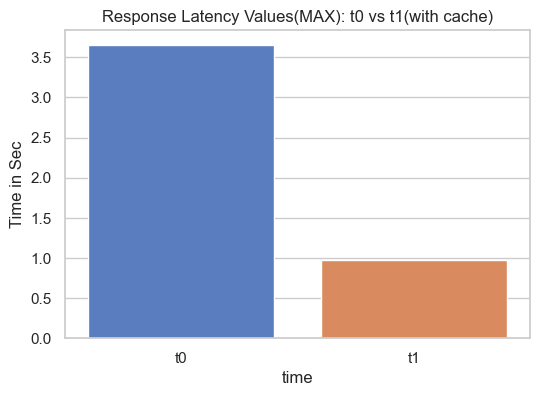

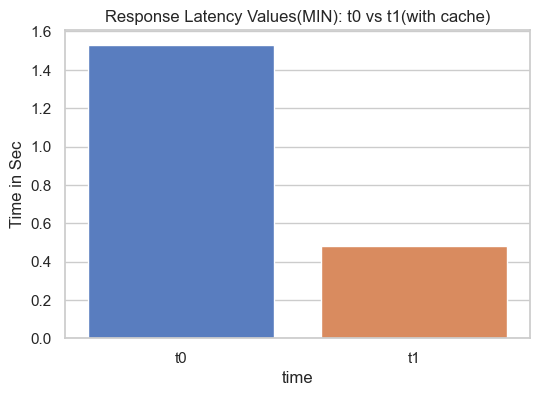

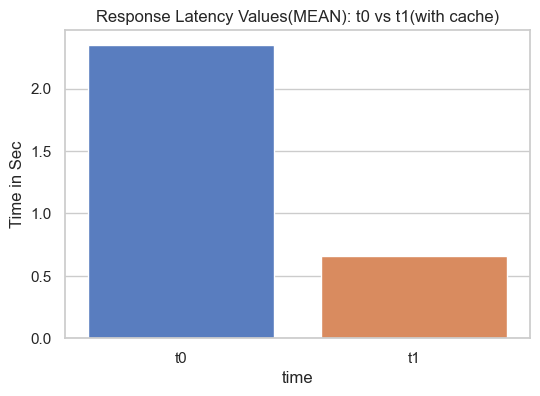

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Data
t0 = {"max": 3.655, "min": 1.53, "mean": 2.35}
t1 = {"max": 0.975, "min": 0.48, "mean": 0.66}

# Convert to DataFrame
data = pd.DataFrame({
    't0': [t0['max'], t0['min'], t0['mean']],
    't1': [t1['max'], t1['min'], t1['mean']]
}, index=['max', 'min', 'mean']).reset_index().melt(id_vars='index', var_name='time', value_name='value')

# Set Seaborn style
sns.set(style="whitegrid", palette="muted")

# 1. MAX plot
plt.figure(figsize=(6,4))
sns.barplot(x='time', y='value', data=data[data['index'] == 'max'])
plt.title('Response Latency Values(MAX): t0 vs t1(with cache)')
plt.ylabel('Time in Sec')
plt.show()

# 2. MIN plot
plt.figure(figsize=(6,4))
sns.barplot(x='time', y='value', data=data[data['index'] == 'min'])
plt.title('Response Latency Values(MIN): t0 vs t1(with cache)')
plt.ylabel('Time in Sec')
plt.show()

# 3. MEAN plot
plt.figure(figsize=(6,4))
sns.barplot(x='time', y='value', data=data[data['index'] == 'mean'])
plt.title('Response Latency Values(MEAN): t0 vs t1(with cache)')
plt.ylabel('Time in Sec')
plt.show()
